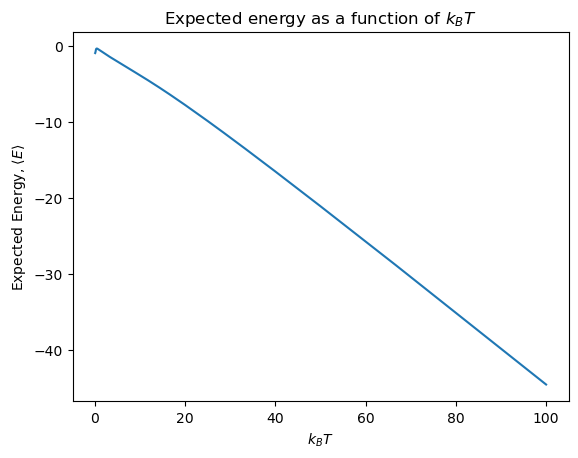

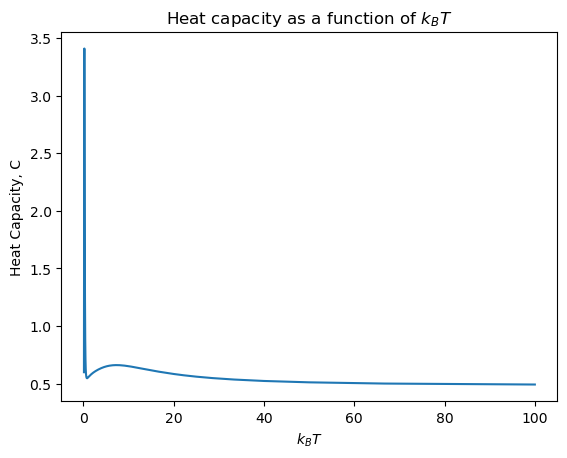

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import CubicSpline

def harmonic_potential(rho):
    return 36*(rho - 1)**2 - 1


def harmonic_force(rho):
    return -72*(rho-1)



def velocity_verlet_integrator(
    initial_position, force_function, dt, max_steps=5_000_000
):
    """
    Integrate one closed orbit using the velocity-Verlet algorithm.

    Starting from (q(0), p(0)) = (q0, 0), the update rule is:

        p_{n+1/2} = p_n       + (dt/2) * F(q_n)
        q_{n+1}   = q_n       + dt     * p_{n+1/2}
        p_{n+1}   = p_{n+1/2} + (dt/2) * F(q_{n+1})

    Integration stops when p changes sign for the second time
    (one full oscillation). Returns None if no orbit is found.
    """

    q, p, t = float(initial_position), 0.0, 0.0
    qs, ps, ts = [q], [p], [t]
    p_prev = 0.0
    zero_crossings = 0

    for _ in range(max_steps):
        # velocity verlet step
        p_half = p + 0.5 * dt * force_function(q)
        q = q + dt * p_half
        p = p_half + 0.5 * dt * force_function(q)
        t += dt

        # accumulate values
        qs.append(q)
        ps.append(p)
        ts.append(t)

        # check momentum sign-change
        if len(qs) > 2 and p_prev * p < 0.0:
            zero_crossings += 1
            # break after complete orbit
            if zero_crossings == 2:
                break
        p_prev = p
    else:
        return None

    return np.array(qs), np.array(ps), np.array(ts)


positions, momenta, time = velocity_verlet_integrator(
    initial_position=1.3,
    force_function=harmonic_force,
    dt=2e-4
)

def total_energy(p, x):
    Kin = 0.5*(p**2)
    Pot = harmonic_potential(x)
    T = np.add(Kin,Pot)
    return T

#lege lijsten initialiseren
q0_test=np.linspace(1.05,2,1000)
energies_test=[]
trajectories=[]
J=[]
dJ_dE=[]

for q0 in q0_test:
    result=velocity_verlet_integrator(q0, harmonic_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    E_test=total_energy(p, x)[0]
    energies_test.append(E_test)
    
energies_test = np.array(energies_test)

energies_values=np.linspace(energies_test.min(), energies_test.max(), 100)
dE = energies_values[1] - energies_values[0]

q0_values = np.interp(energies_values, energies_test, q0_test)

norm = (energies_values - energies_values.min()) / (energies_values.max() - energies_values.min())

for q0 in q0_values:
    result=velocity_verlet_integrator(q0, harmonic_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    trajectories.append((x,p))
    
    A= 0.5 * np.abs(np.sum(x[:-1] * p[1:] - x[1:] * p[:-1]))

    J.append(A/(2*np.pi))

for i in range(len(J)-1):
    dJ = J[i+1] - J[i]
    dJdE = dJ/dE
    dJ_dE.append(dJdE) 

cs = CubicSpline(energies_values, J)   
omega = cs(energies_values, 1) 

betas = np.linspace(0.01,10, 2000)
T=1/betas

#function for partition function Z 
def partition_function(energies, dJ_dE, beta):
    Z = np.sum(dJ_dE * np.exp(-beta * energies) * dE)
    return Z

def partition_free_energy(L, beta):
    Z_free = L/np.sqrt(2*np.pi*beta)
    return Z_free

def partition_function_total(energies, dJ_dE, beta, L):
    Z_bound = partition_function(energies, dJ_dE, beta)
    Z_free = partition_free_energy(L, beta)
    Z_total = Z_bound + Z_free
    return Z_total

def expected_energy(energies, dJ_dE, beta, L):
    Z = partition_function_total(energies, dJ_dE, beta, L)
    expected_E = (np.sum(energies * dJ_dE * np.exp(-beta * energies) * dE) - L/(2*np.sqrt(2*np.pi*beta**3)) ) / Z
    return expected_E

def heat_capacity(energies, dJ_dE, beta, L):
    Z = partition_function_total(energies, dJ_dE, beta, L)
    expected_E = expected_energy(energies, dJ_dE, beta, L)
    d2Z_free = (3 * L) / (4 * np.sqrt(2 * np.pi)) * beta**(-5/2)
    expected_E2 = (np.sum(energies**2 * dJ_dE * np.exp(-beta * energies) * dE) + d2Z_free) / Z
    C = (expected_E2 - expected_E**2) * beta**2
    return C


plt.figure()
plt.plot(T, [expected_energy(energies_values, omega, 1/Temp, L=10) for Temp in T], label='Expected Energy')
plt.title(r'Expected energy as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'Expected Energy, $\langle E \rangle$')
#plt.savefig('expected_energy_L=10.png')
plt.show()


plt.figure()
plt.plot(T, [heat_capacity(energies_values, omega, 1/Temp, L=10) for Temp in T], label='Heat Capacity')
plt.title('Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel('Heat Capacity, C')
#plt.savefig('heat_capacity_L=10.png')
plt.show()


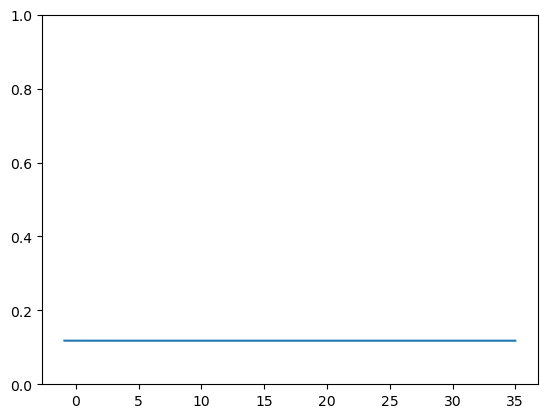

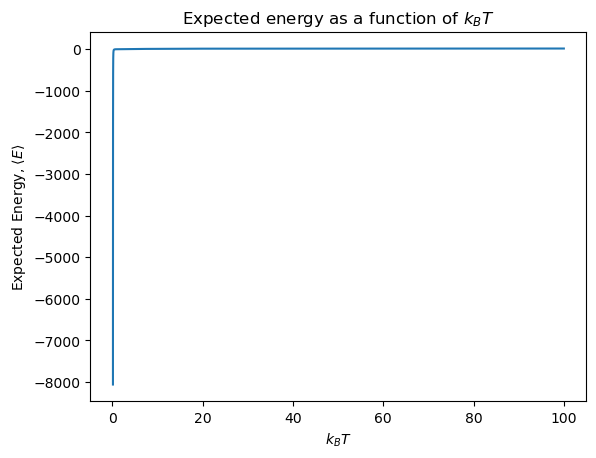

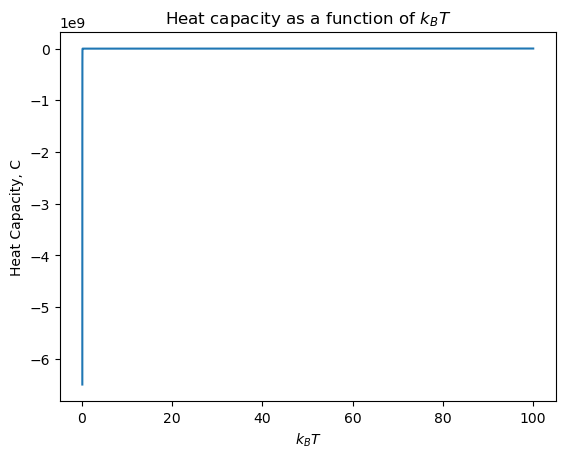

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import CubicSpline

def harmonic_potential(rho):
    return 36*(rho - 1)**2 - 1


def harmonic_force(rho):
    return -72*(rho-1)



def velocity_verlet_integrator(
    initial_position, force_function, dt, max_steps=5_000_000
):
    """
    Integrate one closed orbit using the velocity-Verlet algorithm.

    Starting from (q(0), p(0)) = (q0, 0), the update rule is:

        p_{n+1/2} = p_n       + (dt/2) * F(q_n)
        q_{n+1}   = q_n       + dt     * p_{n+1/2}
        p_{n+1}   = p_{n+1/2} + (dt/2) * F(q_{n+1})

    Integration stops when p changes sign for the second time
    (one full oscillation). Returns None if no orbit is found.
    """

    q, p, t = float(initial_position), 0.0, 0.0
    qs, ps, ts = [q], [p], [t]
    p_prev = 0.0
    zero_crossings = 0

    for _ in range(max_steps):
        # velocity verlet step
        p_half = p + 0.5 * dt * force_function(q)
        q = q + dt * p_half
        p = p_half + 0.5 * dt * force_function(q)
        t += dt

        # accumulate values
        qs.append(q)
        ps.append(p)
        ts.append(t)

        # check momentum sign-change
        if len(qs) > 2 and p_prev * p < 0.0:
            zero_crossings += 1
            # break after complete orbit
            if zero_crossings == 2:
                break
        p_prev = p
    else:
        return None

    return np.array(qs), np.array(ps), np.array(ts)


positions, momenta, time = velocity_verlet_integrator(
    initial_position=1.3,
    force_function=harmonic_force,
    dt=2e-4
)

def total_energy(p, x):
    Kin = 0.5*(p**2)
    Pot = harmonic_potential(x)
    T = np.add(Kin,Pot)
    return T

#lege lijsten initialiseren
q0_test=np.linspace(1.05,2,1000)
energies_test=[]
trajectories=[]
J=[]
dJ_dE=[]

for q0 in q0_test:
    result=velocity_verlet_integrator(q0, harmonic_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    E_test=total_energy(p, x)[0]
    energies_test.append(E_test)
    
energies_test = np.array(energies_test)

energies_values=np.linspace(energies_test.min(), energies_test.max(), 100)
dE = energies_values[1] - energies_values[0]

q0_values = np.interp(energies_values, energies_test, q0_test)

norm = (energies_values - energies_values.min()) / (energies_values.max() - energies_values.min())

for q0 in q0_values:
    result=velocity_verlet_integrator(q0, harmonic_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    trajectories.append((x,p))
    
    A= 0.5 * np.abs(np.sum(x[:-1] * p[1:] - x[1:] * p[:-1]))

    J.append(A/(2*np.pi))

for i in range(len(J)-1):
    dJ = J[i+1] - J[i]
    dJdE = dJ/dE
    dJ_dE.append(dJdE) 

cs = CubicSpline(energies_values, J)   
omega = cs(energies_values, 1) 

betas = np.linspace(0.01,10, 2000)
T=1/betas

#function for partition function Z 
def partition_function(energies, dJ_dE, beta):
    dE = energies[1] - energies[0]
    Z = np.sum(dJ_dE * np.exp(-beta * energies) * dE)
    return Z

def expected_energy(energies, dJ_dE, beta):
    Z = partition_function(energies, dJ_dE, beta)
    dE = energies[1] - energies[0]
    expected_E = np.sum(energies * dJ_dE * np.exp(-beta * energies) * dE) / Z
    return expected_E

def heat_capacity(energies, dJ_dE, beta):
    Z = partition_function(energies, dJ_dE, beta)
    expected_E = expected_energy(energies, dJ_dE, beta)
    dE = energies[1] - energies[0]
    expected_E2 = np.sum(energies**2 * dJ_dE * np.exp(-beta * energies) * dE) / Z
    C = (expected_E2 - expected_E**2) * beta**2 
    return C


plt.figure()
plt.ylim(0,1)
plt.plot(energies_values, omega)
plt.show()

plt.figure()
plt.plot(T, [expected_energy(energies_values, omega, 1/Temp) for Temp in T], label='Expected Energy')
plt.title(r'Expected energy as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'Expected Energy, $\langle E \rangle$')
#plt.savefig('expected_energy.png')
plt.show()


plt.figure()
plt.plot(T, [heat_capacity(energies_values, omega, 1/Temp) for Temp in T], label='Heat Capacity')
plt.title('Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel('Heat Capacity, C')
#plt.savefig('heat_capacity.png')
plt.show()
